### Animal3d Load and analyze using functional maps
First load all relevant packages we need

In [1]:
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import trimesh
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import pyFM
from pyFM.mesh import TriMesh
from pyFM.functional import FunctionalMapping
from pyFM.signatures.HKS_functions import mesh_HKS # run HKS on mesh
from pyFM.signatures.WKS_functions import mesh_WKS # run WKS on mesh
from potpourri3d import MeshHeatMethodDistanceSolver

We first define some helper functions we need:

In [2]:
def plot_mesh(mesh, title="Mesh", color="lightblue", alpha=0.7, ax=None):
    """Plot a trimesh.Trimesh using matplotlib's 3D engine."""
    if ax is None:
        fig = plt.figure(figsize=(6, 5))
        ax = fig.add_subplot(111, projection='3d')

    # Build list of triangle vertex triples
    tris = mesh.vertices[mesh.faces]  # (F, 3, 3)
    poly = Poly3DCollection(tris, alpha=alpha,
                            facecolor=color, edgecolor='gray', linewidth=0.1)
    ax.add_collection3d(poly)

    # Set axis limits
    v = mesh.vertices
    ax.set_xlim(v[:,0].min(), v[:,0].max())
    ax.set_ylim(v[:,1].min(), v[:,1].max())
    ax.set_zlim(v[:,2].min(), v[:,2].max())
    ax.set_title(title)
    ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
    return ax

In [3]:
shape_1_path: str = "C:/Users/ander/Desktop/differential geometry/obj_files/train/n02422106/n02422106_5083.obj"
shape_2_path: str = "C:/Users/ander/Desktop/differential geometry/obj_files/train/n02422106/n02422106_5224.obj"

Now we try and load our meshes we wish to perform alignment on.

In [4]:
shape_1 = trimesh.load(shape_1_path)
shape_2 = trimesh.load(shape_2_path)

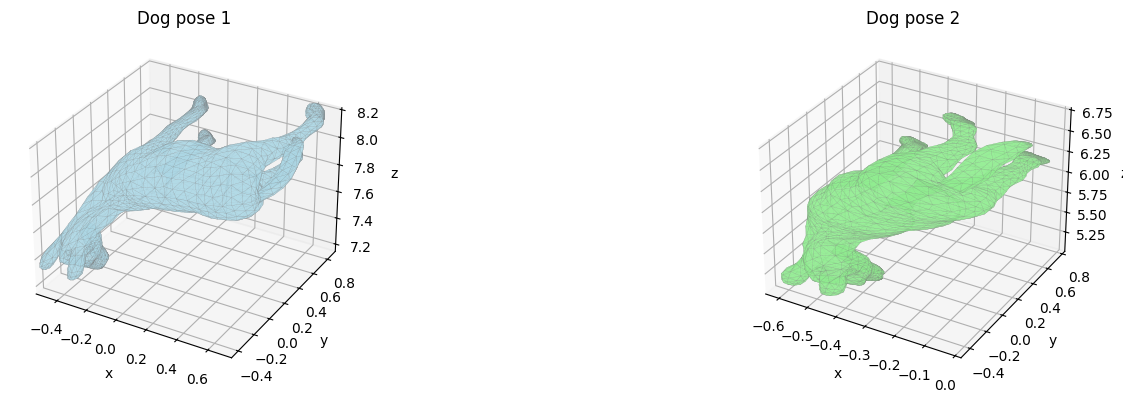

Figure saved.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(18, 4),
                         subplot_kw={'projection': '3d'})
shapes = [(shape_1, "Dog pose 1"), (shape_2, "Dog pose 2")]
colors = ["lightblue", "lightgreen"]
for ax, (m, name), c in zip(axes, shapes, colors):
    plot_mesh(m, title=name, color=c, ax=ax)
plt.tight_layout()
plt.savefig("dogs_posed.png", dpi=100)
plt.show()
print("Figure saved.")

matplotlib makes it look scuffed but atleast we have loaded them in correctly.

now to perform alignment. We have to load the model into pyFMs own model format

In [7]:
shape_1_pyFM = TriMesh(shape_1_path)
shape_2_pyFM = TriMesh(shape_2_path)

# Find the basis functions of our discrete LBO cotangent representation.
shape_1_pyFM.process(k=100)             # computes LBO eigenfunctions
shape_2_pyFM.process(k=100)

# Create and fit a FunctionalMapping object
model = FunctionalMapping(shape_1_pyFM, shape_2_pyFM)
model.k1 = 100 # How many basis
model.k2 = 100

model.mesh1 = shape_1_pyFM
model.mesh2 = shape_2_pyFM

# Set descriptors as attributes, the function preservation constraints for use in
# Ca = b
#model.descr1 = mesh_WKS(shape_1_pyFM, num_E=100)# HKS descriptors, stack 100 different hks runs
#model.descr2 = mesh_WKS(shape_2_pyFM, num_E=100)


model.descr1 = np.hstack([
    mesh_HKS(shape_1_pyFM, num_T=100),
    mesh_WKS(shape_1_pyFM, num_E=100),
])
model.descr2 = np.hstack([
    mesh_HKS(shape_2_pyFM, num_T=100),
    mesh_WKS(shape_2_pyFM, num_E=100),
])

In [8]:
shape_1_pyFM.process(k=100)             # computes LBO eigenfunctions
shape_2_pyFM.process(k=100)

We have found the eigenfunctions for our mesh, we have decided how large C should be, now it is time to estimate the $C_{ij}$ values for the matrix

In [9]:
model.fit(
    w_descr=1.0,
    w_lap=1e-2,
    w_dcomm=1.0,
    w_orient=0.0,
    optinit='identity',   # <-- start from identity, not zeros
    verbose=True
)

Computing commutativity operators
	Scaling LBO commutativity weight by 3.4e-09

Optimization :
	100 Ev on source - 100 Ev on Target
	Using 200 Descriptors
	Hyperparameters :
		Descriptors preservation :1.0e+00
		Descriptors commutativity :1.0e+00
		Laplacian commutativity :1.0e-02
		Orientation preservation :0.0e+00

	Task : CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH, funcall : 262, nit : 251, warnflag : 0
	Done in 82.30 seconds


In [18]:
model.icp_refine(nit=30, overwrite=True)

Mean correspondence error : 0.1027
Median correspondence error: 0.0270


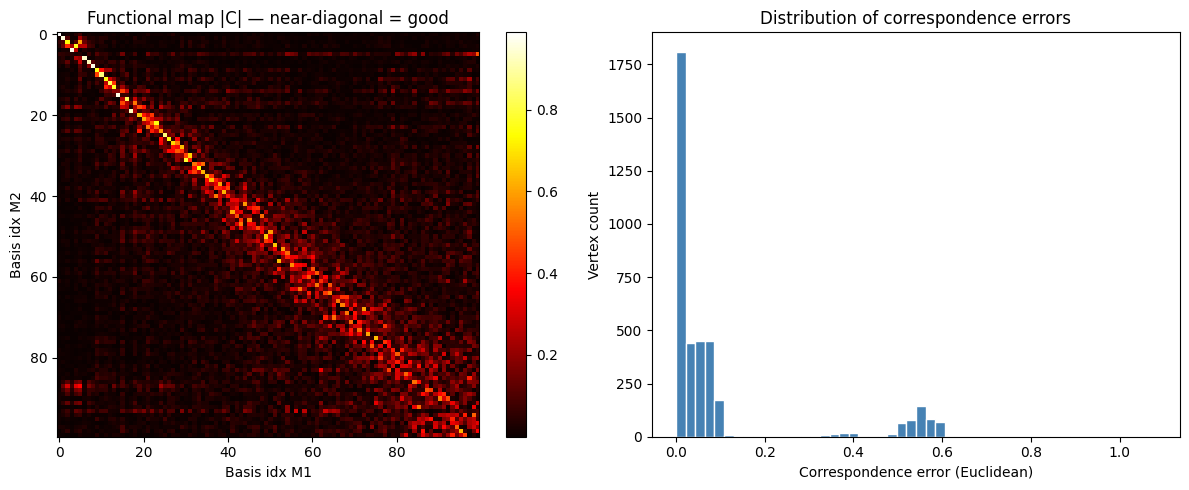

In [19]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

C_pyfm = model.FM

# The functional map matrix — should be near-diagonal for a near-isometry
axes[0].imshow(np.abs(C_pyfm), cmap='hot', aspect='auto')
axes[0].set_title("Functional map |C| — near-diagonal = good")
axes[0].set_xlabel("Basis idx M1")
axes[0].set_ylabel("Basis idx M2")
plt.colorbar(axes[0].images[0], ax=axes[0])

# Get pointwise map and check correspondence quality
T_pyfm = model.get_p2p()

# Colour transfer: assign xyz colours to M1, transfer to M2 via T
V1 = shape_1_pyFM.vertlist
V2 = shape_2_pyFM.vertlist
colors_m1 = (V1 - V1.min(0)) / (V1.max(0) - V1.min(0))   # (N, 3) RGB

colors_m2 = np.zeros_like(colors_m1)
colors_m2[T_pyfm] = colors_m1   # transfer

# Error: distance between predicted and ground-truth (GT = same index, identity map)
err = np.linalg.norm(V2[T_pyfm] - V2[np.arange(len(V2))], axis=1)
print(f"Mean correspondence error : {err.mean():.4f}")
print(f"Median correspondence error: {np.median(err):.4f}")

axes[1].hist(err, bins=50, color='steelblue', edgecolor='white')
axes[1].set_xlabel("Correspondence error (Euclidean)")
axes[1].set_ylabel("Vertex count")
axes[1].set_title("Distribution of correspondence errors")
plt.tight_layout()
plt.show()

Evaluate the results.

In [13]:
import pyFM.eval

In [14]:
K = C_pyfm.shape[0]
diag_mass = np.sum(np.abs(np.diag(C_pyfm))) / np.sum(np.abs(C_pyfm))
print(f"Diagonal mass: {diag_mass:.3f}  (1.0 = perfect isometry)")


Diagonal mass: 0.066  (1.0 = perfect isometry)


In [15]:
# Forward: M1 → M2
T_12 = model.get_p2p()

# Backward: M2 → M1 (swap mesh1/mesh2, refit)
model_rev = FunctionalMapping(shape_2_pyFM, shape_1_pyFM)
model_rev.k1 = 30; model_rev.k2 = 30
model_rev.descr1 = mesh_HKS(shape_2_pyFM, num_T=100)
model_rev.descr2 = mesh_HKS(shape_1_pyFM, num_T=100)
model_rev.fit(w_descr=1.0, w_lap=1e-2, w_dcomm=1.0, optinit='identity')
T_21 = model_rev.get_p2p()

# Cycle consistency: T_21[T_12[i]] should ≈ i
cycle = T_21[T_12]
cycle_error = (cycle != np.arange(len(cycle))).mean()
print(f"Cycle inconsistency: {cycle_error*100:.1f}% of vertices")


Cycle inconsistency: 95.4% of vertices


Since each mesh of the same type has the same amount of verteces in the same spots:

In [20]:
# If both shapes are SMAL-registered: GT map is identity
gt_map = np.arange(shape_1_pyFM.n_vertices)   # vertex i → vertex i
T_pred = model.get_p2p()

# Dense geodesic error (Princeton protocol)
V2 = np.array(shape_2_pyFM.vertlist, dtype=np.float64)
F2 = np.array(shape_2_pyFM.facelist, dtype=np.int32)
solver = MeshHeatMethodDistanceSolver(V2, F2)

errors = []
for i in range(0, len(gt_map), 2):   # subsample for speed
    dist_field = solver.compute_distance(gt_map[i])
    errors.append(dist_field[T_pred[i]])

errors = np.array(errors) / np.sqrt(shape_2_pyFM.area)
print(f"Mean normalised geodesic error: {errors.mean():.4f}")

Mean normalised geodesic error: 0.1131


In [42]:
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "browser"
from plotly.subplots import make_subplots
from scipy.spatial import cKDTree

V1 = np.array(shape_1_pyFM.vertlist)
F1 = np.array(shape_1_pyFM.facelist)
V2 = np.array(shape_2_pyFM.vertlist)
F2 = np.array(shape_2_pyFM.facelist)

shared_camera = dict(
    up=dict(x=0, y=-1, z=0),
    center=dict(x=0, y=0, z=0),
    eye=dict(x=2, y=0, z=0)
)

first_camera = dict(
    up=dict(x=0, y=-1, z=0),
    center=dict(x=0, y=0, z=0),
    eye=dict(x=0, y=0, z=-2)
)

# ── Define colours on shape 1 ─────────────────────────────────────────────────
def xyz_to_rgb(V):
    rgb = (V - V.min(0)) / (V.max(0) - V.min(0) + 1e-8)
    return rgb

colors_m1 = xyz_to_rgb(V1)

# ── Pull transfer: for every vertex on M2, find its source on M1 ──────────────
Phi1 = model.mesh1.eigenvectors[:, :model.k1]   # (N1, k1)
Phi2 = model.mesh2.eigenvectors[:, :model.k2]   # (N2, k2)
C    = model.FM                                  # (k2, k1)

emb2_in_m1_space = Phi2 @ C                     # (N2, k1) — M2 in M1's coordinates
tree = cKDTree(Phi1)
_, T_21 = tree.query(emb2_in_m1_space, k=1)     # (N2,) — every M2 vertex pulls from M1

colors_m2_predicted = colors_m1[T_21]           # no gaps, no black patches

# ── Ground truth transfer ─────────────────────────────────────────────────────
colors_m2_gt = xyz_to_rgb(V1)   # identity map (valid for SMAL-registered meshes)

# ── Convert per-vertex RGB to per-face for plotly ────────────────────────────
def vertex_colors_to_face_str(V, F, colors):
    face_colors = colors[F].mean(axis=1)
    face_colors = np.clip(face_colors, 0, 1)
    return [f"rgb({int(r*255)},{int(g*255)},{int(b*255)})"
            for r, g, b in face_colors]

fc1      = vertex_colors_to_face_str(V1, F1, colors_m1)
fc2_pred = vertex_colors_to_face_str(V2, F2, colors_m2_predicted)
fc2_gt   = vertex_colors_to_face_str(V2, F2, colors_m2_gt)

# ── Plot ──────────────────────────────────────────────────────────────────────
def mesh_trace(V, F, face_colors, name):
    return go.Mesh3d(
        x=V[:,0], y=V[:,1], z=V[:,2],
        i=F[:,0], j=F[:,1], k=F[:,2],
        facecolor=face_colors,
        name=name,
        showscale=False,
        lighting=dict(ambient=0.6, diffuse=0.8, specular=0.2),
    )

fig = make_subplots(
    rows=1, cols=3,
    specs=[[{'type': 'scene'}, {'type': 'scene'}, {'type': 'scene'}]],
    subplot_titles=["Shape 1 (source colours)",
                    "Shape 2 — predicted transfer",
                    "Shape 2 — ground truth transfer"]
)

fig.add_trace(mesh_trace(V1, F1, fc1,      "Shape 1"),      row=1, col=1)
fig.add_trace(mesh_trace(V2, F2, fc2_pred, "Predicted"),    row=1, col=2)
fig.add_trace(mesh_trace(V2, F2, fc2_gt,   "Ground truth"), row=1, col=3)

fig.update_layout(
    width=1300, height=550,
    title="Colour transfer via functional map correspondence",
    scene=dict(aspectmode='data', camera=first_camera),
    scene2=dict(aspectmode='data', camera=shared_camera),
    scene3=dict(aspectmode='data', camera=shared_camera),
)
fig.show()

### Debugging

Check if basis functions align

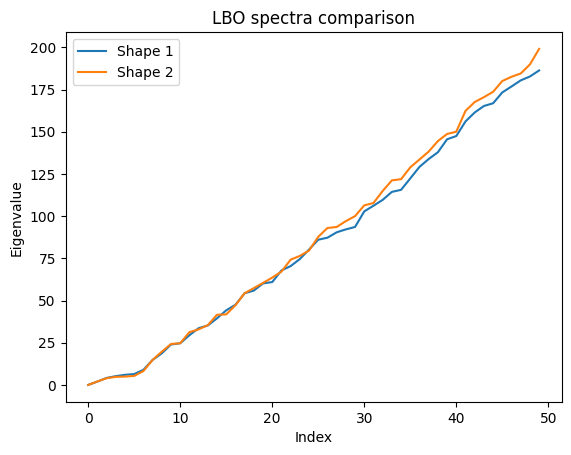

In [15]:
import matplotlib.pyplot as plt
plt.plot(shape_1_pyFM.eigenvalues[:50], label='Shape 1')
plt.plot(shape_2_pyFM.eigenvalues[:50], label='Shape 2')
plt.xlabel('Index'); plt.ylabel('Eigenvalue')
plt.title('LBO spectra comparison')
plt.legend(); plt.show()


Check scale mismatch

In [22]:
print(f"Shape 1 area: {shape_1_pyFM.area:.4f}")
print(f"Shape 2 area: {shape_2_pyFM.area:.4f}")
print(f"Ratio: {shape_1_pyFM.area / shape_2_pyFM.area:.3f}  (should be ~1.0)")


Shape 1 area: 3.1337
Shape 2 area: 2.9794
Ratio: 1.052  (should be ~1.0)


In [23]:
# 3. Are the descriptors actually different between shapes?
print(f"HKS identical: {np.allclose(model.descr1, model.descr2)}")
print(f"HKS correlation: {np.corrcoef(model.descr1.flatten(), model.descr2.flatten())[0,1]:.3f}")
# Correlation ~1.0 means descriptors are too similar → optimiser has no signal
# Correlation ~0.0 means shapes are too different → method will fail
# Correlation 0.7-0.95 is the sweet spot


HKS identical: False
HKS correlation: 0.982


## Landmarks
Have to use these to eliminate ambiguity

In [24]:
import json
import numpy as np

with open("test.json") as f:
    test_data = json.load(f)

keypoint_vids = test_data["keypoint_vids"]

# Pick one representative vertex per keypoint (first in cluster)
landmarks = np.array([vids[0] for vids in keypoint_vids])


print(f"Landmarks: {landmarks}")       # 26 vertex indices
print(f"Num landmarks: {len(landmarks)}")


Landmarks: [1068 2660  910  360 3188 1976 3854  452  416 2156  829 2793   60 2091
  384 2351  221 2754  191   28  498 2463  764 2878 1039    0]
Num landmarks: 26


In [25]:
import json
import numpy as np
from pyFM.mesh import TriMesh
from pyFM.functional import FunctionalMapping

# --- Load landmark vertex indices from annotations ---
with open("test.json") as f:
    test_data = json.load(f)

keypoint_vids = test_data["keypoint_vids"]

# One representative vertex per keypoint (first in cluster)
# Shape (26, 1) — same index applies to both meshes (shared SMAL topology)
landmarks = np.array([[vids[0]] for vids in keypoint_vids])  # (26, 1)
print(f"Using {len(landmarks)} landmark constraints")

# --- Load meshes ---
shape_1_pyFM = TriMesh(shape_1_path)
shape_2_pyFM = TriMesh(shape_2_path)

# --- Preprocess: eigendecomposition + WKS + landmark-conditioned WKS ---
model = FunctionalMapping(shape_1_pyFM, shape_2_pyFM)
model.preprocess(
    n_ev=(100, 100),       # k1, k2 — number of eigenvectors
    n_descr=100,           # WKS descriptor dimension
    descr_type='WKS',      # WKS is sharper than HKS for correspondence
    landmarks=landmarks,   # (26, 1) — shared vertex indices
    verbose=True
)

# --- Fit functional map ---
model.fit(
    w_descr=1.0,
    w_lap=1e-2,
    w_dcomm=1.0,
    w_orient=0.0,
    optinit='identity',    # warm start for near-isometric shapes
    verbose=True
)

# --- Refine ---
model.icp_refine(nit=10, overwrite=True)

C_pyfm = model.FM

Using 26 landmark constraints

Computing Laplacian spectrum
Computing 200 eigenvectors
	Done in 3.67 s
Computing 200 eigenvectors
	Done in 3.17 s

Computing descriptors
	Normalizing descriptors

	2700 out of 2700 possible descriptors kept
Computing commutativity operators
	Scaling LBO commutativity weight by 3.4e-09

Optimization :
	100 Ev on source - 100 Ev on Target
	Using 2700 Descriptors
	Hyperparameters :
		Descriptors preservation :1.0e+00
		Descriptors commutativity :1.0e+00
		Laplacian commutativity :1.0e-02
		Orientation preservation :0.0e+00

	Task : CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH, funcall : 56, nit : 53, warnflag : 0
	Done in 252.36 seconds


In [26]:
import json
import numpy as np
import plotly.graph_objects as go

# --- Load landmarks ---
with open("test.json") as f:
    test_data = json.load(f)

keypoint_vids = test_data["keypoint_vids"]
landmark_indices = np.array([vids[0] for vids in keypoint_vids])  # (26,)

# --- Use shape_1_pyFM (already loaded TriMesh) ---
V = shape_1_pyFM.vertlist   # (N, 3)
F = shape_1_pyFM.facelist   # (M, 3)

lm_coords = V[landmark_indices]  # (26, 3)

fig = go.Figure()

# Mesh surface
fig.add_trace(go.Mesh3d(
    x=V[:, 0], y=V[:, 1], z=V[:, 2],
    i=F[:, 0], j=F[:, 1], k=F[:, 2],
    color='lightblue', opacity=0.6,
    name='Mesh'
))

# Landmark points
fig.add_trace(go.Scatter3d(
    x=lm_coords[:, 0],
    y=lm_coords[:, 1],
    z=lm_coords[:, 2],
    mode='markers+text',
    marker=dict(size=6, color='red'),
    text=[str(i) for i in range(len(landmark_indices))],
    textposition='top center',
    name='Landmarks'
))

fig.update_layout(
    scene=dict(aspectmode='data'),
    title='Landmark vertices on mesh'
)
fig.show()


## Multi-Shape Comparison
Load a base shape and compare it against several targets. For each pair we fit a functional map, transfer colours, and compute the normalised geodesic error.

In [20]:
import json, os
import numpy as np
from pyFM.mesh import TriMesh
from pyFM.functional import FunctionalMapping
from potpourri3d import MeshHeatMethodDistanceSolver
from scipy.spatial import cKDTree

# ── Define base and comparison shapes ────────────────────────────────────────
BASE_PATH = "C:/Users/ander/Desktop/differential geometry/obj_files/train/n02422106/n02422106_5083.obj"

COMPARISON_PATHS = [
    "C:/Users/ander/Desktop/differential geometry/obj_files/train/n02422106/n02422106_5224.obj",
    "C:/Users/ander/Desktop/differential geometry/obj_files/train/n02422106/n02422106_1078.obj",
    "C:/Users/ander/Desktop/differential geometry/obj_files/train/n02422106/n02422106_1120.obj",
    "C:/Users/ander/Desktop/differential geometry/obj_files/train/n02422106/n02422106_1263.obj",
    "C:/Users/ander/Desktop/differential geometry/obj_files/train/n02422106/n02422106_467.obj",
    "C:/Users/ander/Desktop/differential geometry/obj_files/train/n02422106/n02422106_5068.obj",
    "C:/Users/ander/Desktop/differential geometry/obj_files/train/n02422106/n02422106_9612.obj"
]
COMPARISON_NAMES = [os.path.basename(p).replace(".obj", "") for p in COMPARISON_PATHS]

# ── Helpers ───────────────────────────────────────────────────────────────────
def xyz_to_rgb(V):
    return (V - V.min(0)) / (V.max(0) - V.min(0) + 1e-8)

def face_colors_str(V, F, vc):
    fc = np.clip(vc[F].mean(axis=1), 0, 1)
    return [f"rgb({int(r*255)},{int(g*255)},{int(b*255)})" for r, g, b in fc]

# ── Load landmarks ────────────────────────────────────────────────────────────
with open("test.json") as f:
    test_data = json.load(f)
landmarks = np.array([[vids[0]] for vids in test_data["keypoint_vids"]])

# ── Run comparison for each shape ─────────────────────────────────────────────
# results: list of (comp_pyFM, face_colors_str_list, geo_error)
results = []

for idx, (path, name) in enumerate(zip(COMPARISON_PATHS, COMPARISON_NAMES)):
    print(f"\n[{idx+1}/{len(COMPARISON_PATHS)}] {name}")

    base_pyFM = TriMesh(BASE_PATH)
    comp_pyFM = TriMesh(path)

    model = FunctionalMapping(base_pyFM, comp_pyFM)
    model.preprocess(
        n_ev=(100, 100),
        n_descr=100,
        descr_type="HKS",
        landmarks=landmarks,
        verbose=False,
    )
    model.fit(
        w_descr=1.0, w_lap=1e-2, w_dcomm=1.0, w_orient=0.0,
        optinit="identity", verbose=False,
    )
    model.icp_refine(nit=10, overwrite=True)

    # Geodesic error (identity GT map — valid for SMAL-registered meshes)
    V2 = np.array(comp_pyFM.vertlist, dtype=np.float64)
    F2 = np.array(comp_pyFM.facelist, dtype=np.int32)
    solver = MeshHeatMethodDistanceSolver(V2, F2)
    T_pred = model.get_p2p()
    errors = []
    for j in range(0, base_pyFM.n_vertices, 2):
        dist_field = solver.compute_distance(j)
        errors.append(dist_field[T_pred[j]])
    geo_error = float(np.array(errors).mean() / np.sqrt(comp_pyFM.area))

    # Color transfer: pull base RGB onto comp via functional map
    colors_base = xyz_to_rgb(np.array(base_pyFM.vertlist))
    Phi1 = model.mesh1.eigenvectors[:, :model.k1]
    Phi2 = model.mesh2.eigenvectors[:, :model.k2]
    _, T_pull = cKDTree(Phi1).query(Phi2 @ model.FM, k=1)
    fc_comp = face_colors_str(V2, F2, colors_base[T_pull])

    results.append((comp_pyFM, fc_comp, geo_error))
    print(f"  Geo error: {geo_error:.4f}")

print("\nAll comparisons done.")

# Pre-compute base face colours for visualisation
_V_base_tmp = np.array(TriMesh(BASE_PATH).vertlist)
_F_base_tmp = np.array(TriMesh(BASE_PATH).facelist)
_colors_base_tmp = xyz_to_rgb(_V_base_tmp)
BASE_FACE_COLORS = face_colors_str(_V_base_tmp, _F_base_tmp, _colors_base_tmp)
BASE_V = _V_base_tmp
BASE_F = _F_base_tmp


[1/7] n02422106_5224
  Geo error: 0.0151

[2/7] n02422106_1078
  Geo error: 0.0145

[3/7] n02422106_1120
  Geo error: 0.0227

[4/7] n02422106_1263
  Geo error: 0.0134

[5/7] n02422106_467
  Geo error: 0.0202

[6/7] n02422106_5068
  Geo error: 0.0190

[7/7] n02422106_9612
  Geo error: 0.0180

All comparisons done.


In [28]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio
pio.renderers.default = "browser"
import numpy as np

# ── Camera presets ─────────────────────────────────────────────────────────────
shared_camera = dict(up=dict(x=0,y=-1,z=0), center=dict(x=0,y=0,z=0), eye=dict(x=2,y=0,z=0))
first_camera  = dict(up=dict(x=0,y=-1,z=0), center=dict(x=0,y=0,z=0), eye=dict(x=0,y=0,z=-2))

# ── Per-shape camera overrides ─────────────────────────────────────────────────
# None  → use the default (first_camera for base, shared_camera for comparisons)
# Tip   → copy a preset above and change eye=dict(x=?,y=?,z=?) to rotate the view
BASE_CAMERA = None

COMPARISON_CAMERAS = [
    None,  # n02422106_5224
    None,  # n02422106_1078
    dict(up=dict(x=0,y=-1,z=0), center=dict(x=0,y=0,z=0), eye=dict(x=0,y=0,z=-2)),  # shape 2 — front view  # n02422106_1120
    dict(up=dict(x=0,y=-1,z=0), center=dict(x=0,y=0,z=0), eye=dict(x=0,y=0,z=-2)),  # shape 2 — front view  # n02422106_1263
    dict(up=dict(x=0,y=-1,z=0), center=dict(x=0,y=0,z=0), eye=dict(x=0,y=0,z=-2)),  # shape 2 — front view
    dict(up=dict(x=0,y=-1,z=0), center=dict(x=0,y=0,z=0), eye=dict(x=-2,y=0,z=0)),  # shape 2 — front view
    None
]

# ── Helper ─────────────────────────────────────────────────────────────────────
def mesh_trace(V, F, face_colors, name):
    return go.Mesh3d(
        x=V[:,0], y=V[:,1], z=V[:,2],
        i=F[:,0], j=F[:,1], k=F[:,2],
        facecolor=face_colors,
        name=name,
        showscale=False,
        lighting=dict(ambient=0.6, diffuse=0.8, specular=0.2),
    )

# ── Figure 1: Base shape (standalone) ─────────────────────────────────────────
base_cam = BASE_CAMERA if BASE_CAMERA is not None else first_camera
fig_base = go.Figure(mesh_trace(BASE_V, BASE_F, BASE_FACE_COLORS, "Base shape"))
fig_base.update_layout(
    width=600, height=500,
    title=dict(text=f"Base shape: {os.path.basename(BASE_PATH)}", x=0.5),
    scene=dict(aspectmode="data", camera=base_cam),
)
fig_base.show()

# ── Figure 2: Comparison grid ──────────────────────────────────────────────────
n_comp = len(results)
n_cols = 3
n_rows = (n_comp + n_cols - 1) // n_cols

specs  = [[{"type": "scene"}] * n_cols for _ in range(n_rows)]
titles = []
for i in range(n_rows * n_cols):
    if i < n_comp:
        _, _, geo_err = results[i]
        titles.append(f"{COMPARISON_NAMES[i]}<br>Geodesic error: {geo_err:.4f}")
    else:
        titles.append("")

fig_grid = make_subplots(
    rows=n_rows, cols=n_cols,
    specs=specs,
    subplot_titles=titles,
    vertical_spacing=0.10,
    horizontal_spacing=0.02,
)

scene_layout = {}
for idx, (comp_pyFM, fc_comp, geo_error) in enumerate(results):
    row = 1 + idx // n_cols
    col = 1 + idx % n_cols
    V_c = np.array(comp_pyFM.vertlist)
    F_c = np.array(comp_pyFM.facelist)
    fig_grid.add_trace(
        mesh_trace(V_c, F_c, fc_comp, COMPARISON_NAMES[idx]),
        row=row, col=col,
    )
    cam = COMPARISON_CAMERAS[idx] if COMPARISON_CAMERAS[idx] is not None else shared_camera
    sk  = "scene" if idx == 0 else f"scene{idx + 1}"
    scene_layout[sk] = dict(aspectmode="data", camera=cam)

fig_grid.update_layout(
    **scene_layout,
    width=1200,
    height=520 * n_rows,
    title=dict(text="Color transfer: base → comparison shapes", x=0.5),
    showlegend=False,
)
fig_grid.show()